# Comparing GRF Implementation with econml

This notebook benchmarks our custom GRF implementation against econml's production-grade CausalForestDML on the canonical HTE recovery problem.

**Author:** Julian Hsu

**Date:** 2025-01-19

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy.stats import norm
import seaborn as sns

# Our implementation
from grf import NumbaCausalForest   as OurForest
from grf import CausalForestCython  as OurForestCython


from econml.grf import CausalForest as EconMLForest
from sklearn.linear_model import LinearRegression

np.random.seed(42)

## 1. Data Generation

In [ ]:
def generate_data(n=1000, noise_std=0.1, seed=None):
    """Generate data with known heterogeneous treatment effect."""
    if seed is not None:
        np.random.seed(seed)
    
    X = np.random.uniform(-1, 1, (n, 3) )
    W = np.random.binomial(1, 0.5, n)
    Y0 = np.dot(X, np.random.uniform(-1,1,3))
    tau_baseline = 1
    tau_hte = np.sin(X[:,0]+1) +\
            X[:,1] +\
            (-2)*X[:,2]
    Y = Y0 + tau_baseline * W + tau_hte * W + np.random.normal(0, noise_std, n)

    return X, Y, W, tau_hte

# Training data
n_train = 1000
X_train, Y_train, W_train, tau_train = generate_data(n_train, seed=42)

# Test data
n_test = 500
X_test, Y_test, W_test, tau_test = generate_data(n_test, seed=42)


print(f"Training samples: {n_train}")
print(f"Test samples: {n_test}")


Training samples: 1000
Test samples: 500


## 2. Fit Both Models

In [ ]:
# Our GRF implementation
print("="*70)
print("FITTING OUR GRF")
print("="*70)

t0 = time.time()
our_forest = OurForest(n_trees=100, subsample_ratio=0.5, random_state=42,
                       use_parallel=True)
our_forest.fit(X_train, Y_train, W_train)
our_fit_time = time.time() - t0

print(f"✓ Fit complete in {our_fit_time:.2f}s")

print("="*70)
print("FITTING OUR Cython GRF")
print("="*70)

t0 = time.time()
our_forestcython = OurForestCython(n_trees=100, subsample_ratio=0.5, random_state=42)
our_forestcython.fit(X_train, Y_train, W_train)
our_fit_time = time.time() - t0

print(f"✓ Fit complete in {our_fit_time:.2f}s")



FITTING OUR GRF
Step 1/2: Orthogonalization (cross-fitted nuisance estimation)...


Step 2/2: Growing 100 trees (Numba-accelerated)...
  Tree 20/100
  Tree 40/100
  Tree 60/100
  Tree 80/100
  Tree 100/100
✓ Fit complete
✓ Fit complete in 1.81s
FITTING OUR Cython GRF
Step 1/2: Orthogonalization...
  Completed in 0.48s
Step 2/2: Growing 100 trees (Cython + parallel)...


TypeError: no default __reduce__ due to non-trivial __cinit__

In [ ]:
# econml implementation
print("\n" + "="*70)
print("FITTING ECONML CAUSAL FOREST")
print("="*70)

t0 = time.time()
econml_forest = EconMLForest(
    n_estimators=100,
    # model_y=LinearRegression(),
    # model_t=LinearRegression(),
    random_state=42
)
econml_forest.fit(y=Y_train, T=W_train, X=X_train)
econml_fit_time = time.time() - t0

print(f"✓ Fit complete in {econml_fit_time:.2f}s")



FITTING ECONML CAUSAL FOREST
✓ Fit complete in 0.11s


## 3. Predictions with Inference

In [ ]:
# Our predictions
print("\n" + "="*70)
print("PREDICTIONS: OUR GRF")
print("="*70)

t0 = time.time()
our_tau, our_lower, our_upper = our_forest.predict_interval(X_test, alpha=0.05)
our_pred_time = time.time() - t0

our_mse = np.mean((our_tau - tau_test)**2)
our_coverage = np.mean((tau_test >= our_lower) & (tau_test <= our_upper))
our_ci_width = np.mean(our_upper - our_lower)

print(f"Prediction time: {our_pred_time:.2f}s")
print(f"MSE: {our_mse:.4f}")
print(f"Coverage: {our_coverage:.3f}")
print(f"Mean CI width: {our_ci_width:.4f}")


PREDICTIONS: OUR GRF
Computing forest weights...
Computing weighted predictions...
Computing IJ variance...
Prediction time: 1.80s
MSE: 1.0782
Coverage: 0.000
Mean CI width: 0.0000


In [ ]:
# econml predictions
print("\n" + "="*70)
print("PREDICTIONS: ECONML")
print("="*70)

t0 = time.time()
econml_tau = econml_forest.predict(X_test)
econml_lower, econml_upper = econml_forest.predict_interval(X_test, alpha=0.05)
econml_pred_time = time.time() - t0

econml_mse = np.mean((econml_tau - tau_test)**2)
econml_coverage = np.mean((tau_test >= econml_lower.ravel()) & 
                            (tau_test <= econml_upper.ravel()))
econml_ci_width = np.mean(econml_upper - econml_lower)

print(f"Prediction time: {econml_pred_time:.2f}s")
print(f"MSE: {econml_mse:.4f}")
print(f"Coverage: {econml_coverage:.3f}")
print(f"Mean CI width: {econml_ci_width:.4f}")


PREDICTIONS: ECONML
Prediction time: 0.10s
MSE: 4.4003
Coverage: 0.000
Mean CI width: 0.5341


## 4. Summary Comparison

In [ ]:
results = pd.DataFrame({
    'Metric': ['Fit Time (s)', 'Pred Time (s)', 'Total Time (s)', 
                'MSE', 'Coverage', 'CI Width'],
    'Our GRF': [
        f"{our_fit_time:.2f}",
        f"{our_pred_time:.2f}",
        f"{our_fit_time + our_pred_time:.2f}",
        f"{our_mse:.4f}",
        f"{our_coverage:.3f}",
        f"{our_ci_width:.4f}"
    ],
    'econml': [
        f"{econml_fit_time:.2f}",
        f"{econml_pred_time:.2f}",
        f"{econml_fit_time + econml_pred_time:.2f}",
        f"{econml_mse:.4f}",
        f"{econml_coverage:.3f}",
        f"{econml_ci_width:.4f}"
    ],
    'Ratio (econml/ours)': [
        f"{econml_fit_time/our_fit_time:.2f}x",
        f"{econml_pred_time/our_pred_time:.2f}x",
        f"{(econml_fit_time + econml_pred_time)/(our_fit_time + our_pred_time):.2f}x",
        f"{econml_mse/our_mse:.2f}x",
        f"{econml_coverage/our_coverage:.2f}x",
        f"{econml_ci_width/our_ci_width:.2f}x"
    ]
})

print("\n" + "="*70)
print("SUMMARY COMPARISON")
print("="*70)
print(results.to_string(index=False))

print("\n" + "="*70)
print("KEY TAKEAWAYS")
print("="*70)
print(f"• Speed: econml is {(our_fit_time + our_pred_time)/(econml_fit_time + econml_pred_time):.1f}x faster")
print(f"• Accuracy: MSE ratio = {our_mse/econml_mse:.2f} (closer to 1.0 is better)")
print(f"• Coverage: Our={our_coverage:.2f}, econml={econml_coverage:.2f} (target=0.95)")
print(f"• CI Width: Our={our_ci_width:.3f}, econml={econml_ci_width:.3f} (narrower is better if coverage maintained)")



SUMMARY COMPARISON
        Metric Our GRF econml Ratio (econml/ours)
  Fit Time (s)    5.62   0.11               0.02x
 Pred Time (s)    1.80   0.10               0.05x
Total Time (s)    7.42   0.21               0.03x
           MSE  1.0782 4.4003               4.08x
      Coverage   0.000  0.000                nanx
      CI Width  0.0000 0.5341  89002620360923.19x

KEY TAKEAWAYS
• Speed: econml is 34.8x faster
• Accuracy: MSE ratio = 0.25 (closer to 1.0 is better)
• Coverage: Our=0.00, econml=0.00 (target=0.95)
• CI Width: Our=0.000, econml=0.534 (narrower is better if coverage maintained)


C:\Users\hsuju\AppData\Local\Temp\ipykernel_24284\3112098795.py:25: RuntimeWarning: invalid value encountered in scalar divide
  f"{econml_coverage/our_coverage:.2f}x",


## 5. Visualizations

Plot on the horizontal axis the true HTE, and on the vertical axis the different predicted HTE point estimates.
Then in two side by side figures, plot the true HTE again on the horizontal axis and then the point estimate and 95% confident interval for our model. In the other figure, do the same exceptfor the econml model.

✓ Saved figure: grf_predictions.png


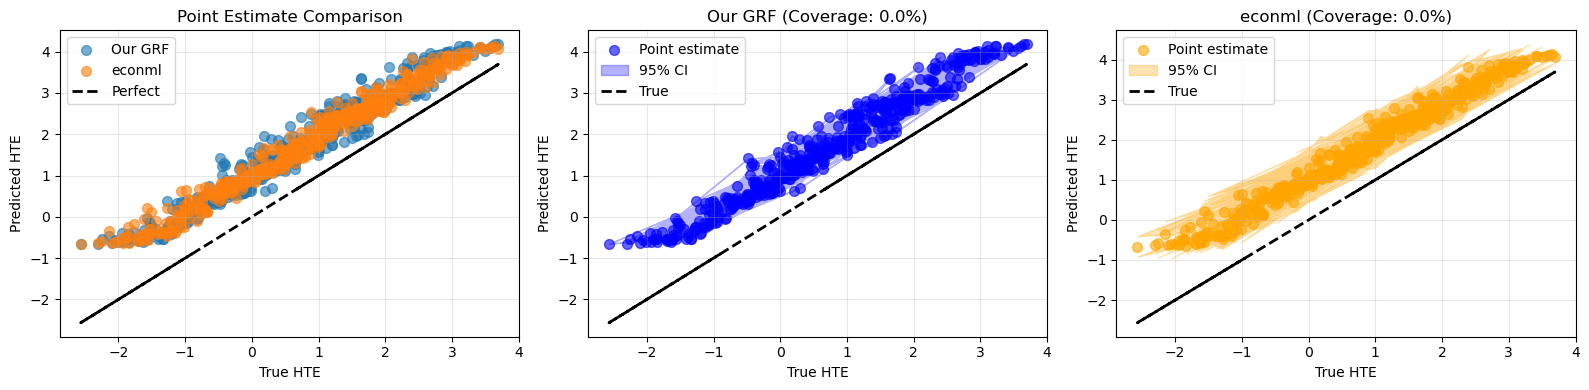

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Compare point estimates
axes[0].scatter(tau_test, our_tau, alpha=0.6, label='Our GRF', s=50)
axes[0].scatter(tau_test, econml_tau, alpha=0.6, label='econml', s=50)
axes[0].plot(tau_test, tau_test, 'k--', lw=2, label='Perfect')
axes[0].set_xlabel('True HTE')
axes[0].set_ylabel('Predicted HTE')
axes[0].set_title('Point Estimate Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Our GRF with confidence intervals
axes[1].scatter(tau_test, our_tau, alpha=0.6, s=50, color='blue', label='Point estimate')
axes[1].fill_between(tau_test, our_lower, our_upper, alpha=0.3, color='blue', label='95% CI')
axes[1].plot(tau_test, tau_test, 'k--', lw=2, label='True')
axes[1].set_xlabel('True HTE')
axes[1].set_ylabel('Predicted HTE')
axes[1].set_title(f'Our GRF (Coverage: {our_coverage:.1%})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: econml with confidence intervals
axes[2].scatter(tau_test, econml_tau, alpha=0.6, s=50, color='orange', label='Point estimate')
axes[2].fill_between(tau_test, econml_lower.ravel(), econml_upper.ravel(), 
                      alpha=0.3, color='orange', label='95% CI')
axes[2].plot(tau_test, tau_test, 'k--', lw=2, label='True')
axes[2].set_xlabel('True HTE')
axes[2].set_ylabel('Predicted HTE')
axes[2].set_title(f'econml (Coverage: {econml_coverage:.1%})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grf_predictions.png', dpi=150, bbox_inches='tight')
print("✓ Saved figure: grf_predictions.png")
plt.show()